# Прогнозирование акций «Лукойл»: расширение признаков и многомасштабное окно входа

В работе решается задача прогнозирования цены закрытия акций компании «Лукойл» с двумя усовершенствованиями по сравнению с базовым подходом:

1. **Расширение признакового пространства.** К исходным пяти каналам (OPEN, MAX, MIN, CLOSE, VOLUME) добавляются производные характеристики: попарные разности каналов, модули попарных разностей, попарные произведения, обратные значения каналов, первые и вторые производные каждого канала по времени.
2. **Многомасштабное окно входа.** На вход сети подаётся не одно непрерывное окно, а объединение двух участков прошлого: 100 точек с шагом 1 (ближайшее прошлое в высоком разрешении) и 100 точек с шагом 10, представленных средними по соответствующим отрезкам (более дальняя история в низком разрешении). Такой формат позволяет сети одновременно учитывать тонкую структуру недавних данных и общий тренд за более продолжительный период.

## Подготовка

In [ ]:
# Работа с массивами
import numpy as np

# Работа с таблицами
import pandas as pd

# Классы-конструкторы моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model

# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, LSTM, MaxPooling1D

# Оптимизаторы
from tensorflow.keras.optimizers import Adam

# Генератор выборки временных рядов
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Нормировщики
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Колбэк
from tensorflow.keras.callbacks import LearningRateScheduler

# Загрузка датасетов из облака google
import gdown

# Отрисовка графиков
import matplotlib.pyplot as plt

# Отрисовка графики в ячейке colab
%matplotlib inline

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Назначение размера и стиля графиков по умолчанию
from pylab import rcParams
plt.style.use('ggplot')
rcParams['figure.figsize'] = (14, 7)

In [ ]:
# Загрузка датасетов из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/16_17.csv', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/18_19.csv', None, quiet=True)

'18_19.csv'

In [ ]:
# Чтение данных в таблицы с удалением ненужных столбцов
data16_17 = pd.read_csv('16_17.csv', sep=';').drop(columns=['DATE', 'TIME'])
data18_19 = pd.read_csv('18_19.csv', sep=';').drop(columns=['DATE', 'TIME'])

In [ ]:
# Просмотр размерностей получившихся таблиц
print(data16_17.shape)
print(data18_19.shape)

(263925, 5)
(217947, 5)


In [ ]:
# Создание общего набора данных из двух датасетов
data = pd.concat([data16_17, data18_19])           # Объединение датасетов
data = data.reset_index(drop=True)                 # Обнуление индексов

# Проверка формы данных
print(data.shape)

(481872, 5)


## Расширение исходного сигнала

К пяти исходным каналам добавляется набор производных характеристик. Все новые столбцы вычисляются непосредственно в DataFrame и сохраняют выравнивание по строкам с исходными данными.

In [ ]:
# Получение названий столбцов
col = data.columns
print(col)

Index(['OPEN', 'MAX', 'MIN', 'CLOSE', 'VOLUME'], dtype='object')


**Попарные разности, модули разностей и произведения каналов.** Перебираются все упорядоченные пары столбцов исходных каналов, для каждой пары формируются три новых столбца с информативными именами. Имена строятся из имён двух исходных каналов и символа операции.

In [ ]:
# Задание циклов для столбцов таким образом, чтобы происходил перебор всех возможных пар:
# Перебор индексов массива с именами столбцов 'OPEN', 'MAX', 'MIN', 'CLOSE', 'VOLUME',
# получая пары 'OPEN' и 'MAX', 'OPEN' и 'MIN', 'OPEN' и 'CLOSE' ..., 'MAX' и 'MIN', 'MAX' и 'CLOSE' и т.д.

for i in range(col.shape[0]):                                      # Для всех пар
    for j in range(i + 1, col.shape[0]):                           # Расчет
        data[col[i] + '-' + col[j]] = data[col[i]] - data[col[j]]                # Разности
        data['|' + col[i] + '-' + col[j] + '|'] = abs(data[col[i]] - data[col[j]])  # Модули разностей
        data[col[i] + '*' + col[j]] = data[col[i]] * data[col[j]]                # Произведения

**Обратные значения, первые и вторые производные.** Для каждого исходного канала вычисляются три величины: обратное значение по формуле `1 / (x + 1e-3)` (константа в знаменателе исключает деление на ноль), первая производная как разность соседних значений и вторая производная по схеме `x[n] - 2·x[n-1] + x[n-2]`. Производные определены не на всех индексах, поэтому первые одна-две позиции соответствующих столбцов остаются NaN.

In [ ]:
# Для каждого столбца 'OPEN', 'MAX', 'MIN', 'CLOSE', 'VOLUME' расчет:
for i in col:
    # Обратные значения. 1e-3 в формуле нужно, чтобы случайно не разделить на 0
    data['Обратный ' + i] = 1 / (data[i] + 1e-3)
    # Создание пустого столбца
    data['Производная от ' + i] = np.nan
    # При помощи срезов расчет первых производных, .reset_index(drop=True) нужен для корректных расчетов
    data['Производная от ' + i][1:] = data[i][1:].reset_index(drop=True) - data[i][:-1].reset_index(drop=True)
    # Создание пустого столбца
    data['Вторая производная от ' + i] = np.nan
    # При помощи срезов расчет вторых производных
    data['Вторая производная от ' + i][2:] = data[i][2:].reset_index(drop=True) - 2 * data[i][1:-1].reset_index(drop=True) + data[i][:-2].reset_index(drop=True)

In [ ]:
# Просмотр результатов
data

,OPEN,MAX,MIN,CLOSE,VOLUME,OPEN-MAX,|OPEN-MAX|,OPEN*MAX,OPEN-MIN,|OPEN-MIN|,...,Вторая производная от MAX,Обратный MIN,Производная от MIN,Вторая производная от MIN,Обратный CLOSE,Производная от CLOSE,Вторая производная от CLOSE,Обратный VOLUME,Производная от VOLUME,Вторая производная от VOLUME
0,2351.0,2355.8,2350.0,2350.0,2547,-4.8,4.8,5538485.80,1.0,1.0,...,NaN,0.000426,NaN,NaN,0.000426,NaN,NaN,0.000393,NaN,NaN
1,2352.9,2355.7,2350.0,2355.7,195,-2.8,2.8,5542726.53,2.9,2.9,...,NaN,0.000426,0.0,NaN,0.000425,5.7,NaN,0.005128,-2352.0,NaN
2,2355.6,2356.0,2351.4,2354.1,257,-0.4,0.4,5549793.60,4.2,4.2,...,0.4,0.000425,1.4,1.4,0.000425,-1.6,-7.3,0.003891,62.0,2414.0
3,2354.5,2355.0,2351.2,2353.7,763,-0.5,0.5,5544847.50,3.3,3.3,...,-1.3,0.000425,-0.2,-1.6,0.000425,-0.4,1.2,0.001311,506.0,444.0
4,2353.1,2353.9,2353.1,2353.6,231,-0.8,0.8,5538962.09,0.0,0.0,...,-0.1,0.000425,1.9,2.1,0.000425,-0.1,0.3,0.004329,-532.0,-1038.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481867,5183.5,5183.5,5183.5,5183.5,31523,0.0,0.0,26868672.25,0.0,0.0,...,11.5,0.000193,16.0,18.0,0.000193,11.5,10.0,0.000032,29174.0,29480.0
481868,5183.5,5183.5,5183.5,5183.5,5090,0.0,0.0,26868672.25,0.0,0.0,...,-11.5,0.000193,0.0,-16.0,0.000193,0.0,-11.5,0.000196,-26433.0,-55607.0
481869,5183.5,5183.5,5183.5,5183.5,230,0.0,0.0,26868672.25,0.0,0.0,...,0.0,0.000193,0.0,0.0,0.000193,0.0,0.0,0.004348,-4860.0,21573.0
481870,5183.5,5183.5,5183.5,5183.5,5,0.0,0.0,26868672.25,0.0,0.0,...,0.0,0.000193,0.0,0.0,0.000193,0.0,0.0,0.199960,-225.0,4635.0


После добавления всех производных столбцов первые две строки таблицы содержат NaN (вторая производная не определена для индексов 0 и 1, первая — для индекса 0). Эти строки отбрасываются, а итоговые данные переводятся в массив NumPy.

In [ ]:
# Использование всех столбцов, кроме первых двух
data = np.array(data.iloc[2:])

# Перевод в numpy
data = np.array(data)

# Переменная, для использования одной и той же архитектуры под разные матрицы
columnsAmount = data.shape[1]

print('Форма расширенного массива данных:', data.shape)
print('Число каналов на входе сети:', columnsAmount)

Форма расширенного массива данных: (481870, 50)
Число каналов на входе сети: 50


## Целевая переменная и нормализация

В качестве предсказываемой величины используется цена закрытия (канал CLOSE — индекс 3 в исходных столбцах). Данные разделяются на обучающую и тестовую части в хронологическом порядке. Нормировщики обучаются только на обучающей выборке, чтобы исключить утечку информации о тесте; масштабирование входов и выхода выполняется раздельно.

In [ ]:
# Индекс канала CLOSE в исходных столбцах
CLOSE_INDEX = 3

# Гиперпараметры разделения и формирования окон
NEAR_LEN = 100         # Число точек ближнего окна (шаг 1)
FAR_LEN = 100          # Число точек дальнего окна (шаг 10)
FAR_STRIDE = 10        # Шаг для дальнего окна
SEQ_LEN = NEAR_LEN + FAR_LEN  # Итоговая длина входа сети

TEST_LEN = 30000                      # Размер тестовой части
TRAIN_LEN = data.shape[0] - TEST_LEN  # Размер обучающей части
GAP = 2 * (NEAR_LEN + FAR_LEN * FAR_STRIDE)  # Зазор между обучением и тестом

In [ ]:
# Разделение по времени с зазором
data_train = data[:TRAIN_LEN]
data_test = data[TRAIN_LEN + GAP:]

# Целевые ряды (только канал CLOSE) для обучения и теста
y_train_raw = data_train[:, CLOSE_INDEX].reshape(-1, 1)
y_test_raw  = data_test[:, CLOSE_INDEX].reshape(-1, 1)

# Нормировщики, настроенные на тренировочной части
x_scaler = StandardScaler()
x_scaler.fit(data_train)

y_scaler = MinMaxScaler()
y_scaler.fit(y_train_raw)

# Преобразование
x_train_sc = x_scaler.transform(data_train)
x_test_sc  = x_scaler.transform(data_test)
y_train_sc = y_scaler.transform(y_train_raw)
y_test_sc  = y_scaler.transform(y_test_raw)

print('Train  X:', x_train_sc.shape, 'Y:', y_train_sc.shape)
print('Test   X:', x_test_sc.shape,  'Y:', y_test_sc.shape)

Train  X: (451870, 50) Y: (451870, 1)
Test   X: (27800, 50) Y: (27800, 1)


## Формирование многомасштабного окна входа

Для каждой целевой точки `t` входной сигнал собирается из двух частей:

- **Ближнее окно.** 100 значений непосредственно перед точкой `t` с шагом 1: индексы `t-100, t-99, …, t-1`. Это детальное представление недавней динамики.
- **Дальнее окно.** 100 значений, покрывающих более длинный отрезок прошлого с шагом 10. Каждая точка дальнего окна — среднее по 10 последовательным значениям соответствующего отрезка. Это сглаженное представление более дальней истории.

Обе части склеиваются по оси времени, и сеть получает на вход один тензор формы `(SEQ_LEN, channels)`, где `SEQ_LEN = 200`. Усреднение по отрезку из 10 точек выбрано как способ снизить шум при увеличении горизонта просмотра в прошлое.

Размер ряда исключает возможность хранить все окна в памяти одновременно: при ~450 тысячах точек, длине окна 200 и 50 каналах общий массив занимал бы порядка десятка гигабайт. Поэтому окна формируются на лету в специальном классе `keras.utils.Sequence`, который выдаёт батчи по запросу `model.fit`. В памяти при этом хранится только сам исходный ряд и небольшой текущий батч.

In [ ]:
from tensorflow.keras.utils import Sequence

class MultiscaleSequence(Sequence):
    def __init__(self, x_data, y_data,
                 near_len=100, far_len=100, far_stride=10,
                 batch_size=64, shuffle=True):
        self.x_data = x_data
        self.y_data = y_data
        self.near_len = near_len
        self.far_len = far_len
        self.far_stride = far_stride
        self.far_span = far_len * far_stride
        self.total_back = self.far_span + near_len   # Сколько точек прошлого нужно для одного примера
        self.batch_size = batch_size
        self.shuffle = shuffle

        n_total = x_data.shape[0]
        if n_total <= self.total_back:
            raise ValueError('Слишком короткий ряд для заданных размеров окон')

        # Допустимые целевые индексы t
        self.indices = np.arange(self.total_back, n_total)
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        # Число батчей в одной эпохе
        return int(np.ceil(len(self.indices) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        # Индексы целевых точек, попадающих в батч номер idx
        batch_t = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        n_ch = self.x_data.shape[1]

        x_batch = np.empty((len(batch_t), self.far_len + self.near_len, n_ch), dtype=np.float32)
        y_batch = np.empty((len(batch_t),) + self.y_data.shape[1:], dtype=np.float32)

        for k, t in enumerate(batch_t):
            # Ближнее окно
            near = self.x_data[t - self.near_len:t]
            # Дальнее окно с усреднением по отрезкам
            far_block_end = t - self.near_len
            far_block_start = far_block_end - self.far_span
            far_block = self.x_data[far_block_start:far_block_end]
            far = far_block.reshape(self.far_len, self.far_stride, n_ch).mean(axis=1)

            x_batch[k, :self.far_len] = far
            x_batch[k, self.far_len:] = near
            y_batch[k] = self.y_data[t]

        return x_batch, y_batch

In [ ]:
# Параметры обучения и создание ленивых генераторов
BATCH_SIZE = 64

train_seq = MultiscaleSequence(x_train_sc, y_train_sc,
                               near_len=NEAR_LEN, far_len=FAR_LEN, far_stride=FAR_STRIDE,
                               batch_size=BATCH_SIZE, shuffle=True)
test_seq = MultiscaleSequence(x_test_sc, y_test_sc,
                              near_len=NEAR_LEN, far_len=FAR_LEN, far_stride=FAR_STRIDE,
                              batch_size=BATCH_SIZE, shuffle=False)

# Форма одного батча для определения входного слоя сети
xb_sample, yb_sample = train_seq[0]
print('Форма батча X:', xb_sample.shape, '  Y:', yb_sample.shape)
print('Батчей в обучающем наборе:', len(train_seq))
print('Батчей в тестовом наборе :', len(test_seq))

Форма батча X: (64, 200, 50)   Y: (64, 1)
Батчей в обучающем наборе: 7044
Батчей в тестовом наборе : 418


In [ ]:
# Утилита для сбора прогноза и эталона по всему тестовому набору одним проходом.
# Используется после обучения для построения графиков и оценки качества.
def collect_predictions(model, seq):
    preds, trues = [], []
    for i in range(len(seq)):
        xb, yb = seq[i]
        preds.append(model.predict(xb, verbose=0))
        trues.append(yb)
    return np.concatenate(preds, axis=0), np.concatenate(trues, axis=0)

## Полносвязная сеть

Базовая архитектура для проверки качества признаков и многомасштабного входа: разворачивание тензора окна в одномерный вектор и последовательность полносвязных слоёв с регуляризацией.

In [ ]:
# Полносвязная архитектура
model_dense = Sequential()
model_dense.add(Flatten(input_shape=xb_sample.shape[1:]))
model_dense.add(Dense(256, activation='relu'))
model_dense.add(Dropout(0.3))
model_dense.add(Dense(128, activation='relu'))
model_dense.add(Dense(1, activation='linear'))

model_dense.compile(loss='mse', optimizer=Adam(learning_rate=1e-4))
model_dense.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,281 (9.89 MB)

 Trainable params: 2,593,281 (9.89 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Обучение
history_dense = model_dense.fit(train_seq,
                                validation_data=test_seq,
                                epochs=15,
                                verbose=1)

Epoch 1/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 132s 18ms/step - loss: 0.1384 - val_loss: 0.0186
Epoch 2/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 119s 17ms/step - loss: 0.0487 - val_loss: 0.0171
Epoch 3/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 119s 17ms/step - loss: 0.0248 - val_loss: 0.0092
Epoch 4/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 118s 17ms/step - loss: 0.0227 - val_loss: 0.0243
Epoch 5/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 119s 17ms/step - loss: 0.0187 - val_loss: 0.0109
Epoch 6/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 119s 17ms/step - loss: 0.0155 - val_loss: 0.0191
Epoch 7/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 118s 17ms/step - loss: 0.0164 - val_loss: 0.0134
Epoch 8/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 119s 17ms/step - loss: 0.0128 - val_loss: 0.0187
Epoch 9/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 119s 17ms/step - loss: 0.0119 - val_loss: 0.0136
Epoch 10/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 120s 17ms/step - loss: 0.0107 - val_loss: 0.0149
Epoch 11/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 122s 17ms/step - loss: 0.0108 - val_loss: 0.02

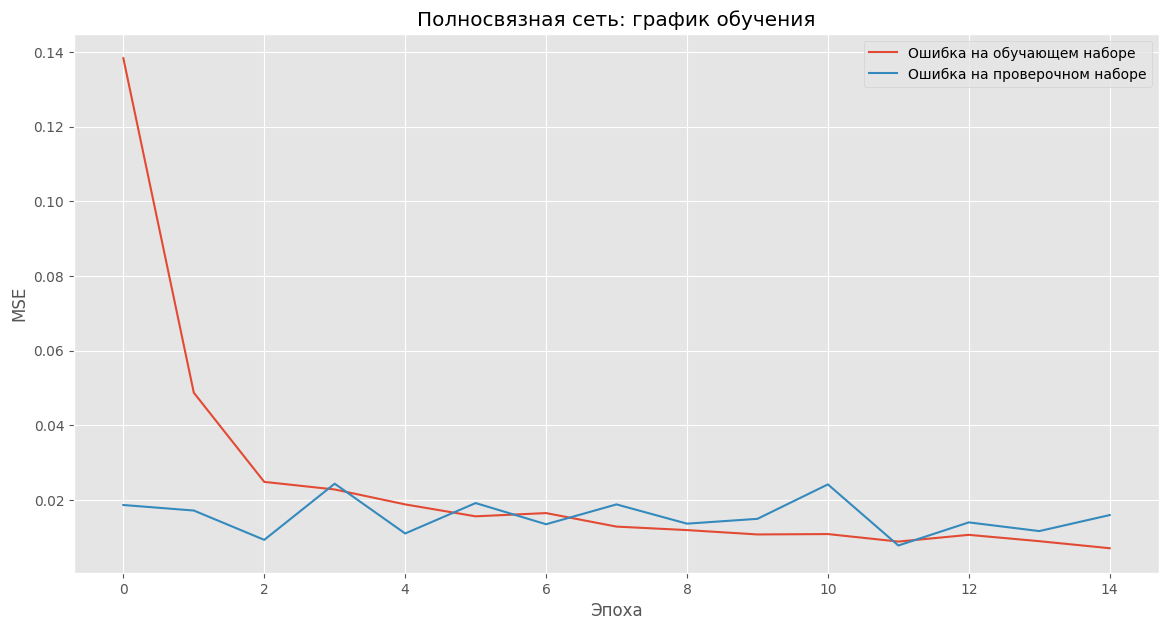

In [ ]:
# График ошибки обучения
plt.figure(figsize=(14, 7))
plt.plot(history_dense.history['loss'], label='Ошибка на обучающем наборе')
plt.plot(history_dense.history['val_loss'], label='Ошибка на проверочном наборе')
plt.title('Полносвязная сеть: график обучения')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.show()

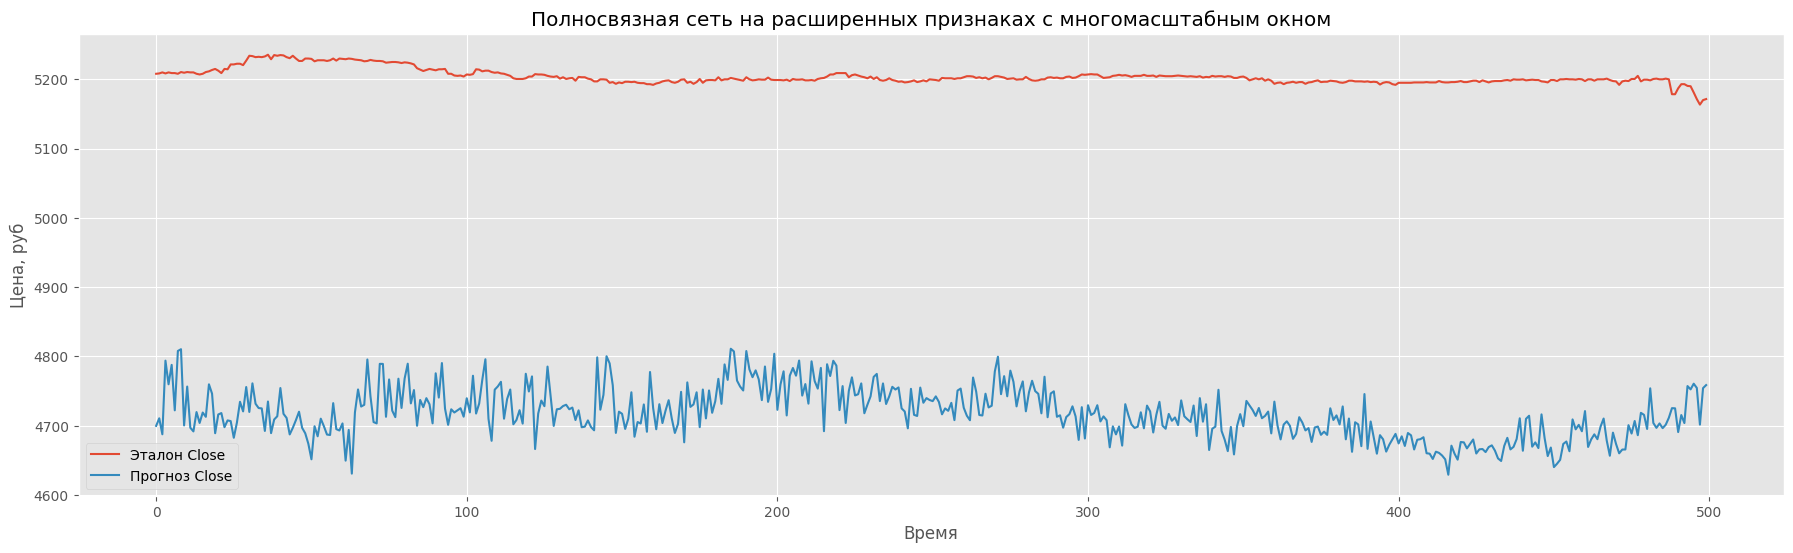

In [ ]:
# Предсказание и обратная нормализация
y_pred_dense_sc, y_true_sc = collect_predictions(model_dense, test_seq)
y_pred_dense = y_scaler.inverse_transform(y_pred_dense_sc)
y_true_close = y_scaler.inverse_transform(y_true_sc)

# Сопоставление прогноза и эталона
start = 0
length = 500

plt.figure(figsize=(22, 6))
plt.plot(y_true_close[start:start + length], label='Эталон Close')
plt.plot(y_pred_dense[start:start + length], label='Прогноз Close')
plt.title('Полносвязная сеть на расширенных признаках с многомасштабным окном')
plt.xlabel('Время')
plt.ylabel('Цена, руб')
plt.legend()
plt.show()

## Свёрточная сеть Conv1D

Альтернативная архитектура: одномерные свёртки выделяют локальные паттерны вдоль временной оси склеенного окна. Подмешивание дальнего сглаженного контекста перед ближним детализированным окном делает структуру входа неравномерной во времени, и свёрточная сеть способна обрабатывать её, опираясь на локальные признаки в обеих частях.

In [ ]:
# Свёрточная архитектура
model_conv = Sequential()
model_conv.add(Conv1D(64, 5, padding='same', activation='relu',
                      input_shape=xb_sample.shape[1:]))
model_conv.add(Conv1D(64, 5, padding='same', activation='relu'))
model_conv.add(MaxPooling1D(pool_size=2))
model_conv.add(Conv1D(128, 5, padding='same', activation='relu'))
model_conv.add(MaxPooling1D(pool_size=2))
model_conv.add(Flatten())
model_conv.add(Dense(128, activation='relu'))
model_conv.add(Dropout(0.3))
model_conv.add(Dense(1, activation='linear'))

model_conv.compile(loss='mse', optimizer=Adam(learning_rate=1e-4))
model_conv.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 64)        │        16,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 200, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 100, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,153 (3.42 MB)

 Trainable params: 897,153 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Обучение
history_conv = model_conv.fit(train_seq,
                              validation_data=test_seq,
                              epochs=15,
                              verbose=1)

Epoch 1/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 140s 19ms/step - loss: 0.0111 - val_loss: 5.5969e-04
Epoch 2/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 133s 19ms/step - loss: 0.0018 - val_loss: 1.7644e-04
Epoch 3/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 127s 18ms/step - loss: 0.0012 - val_loss: 3.1574e-05
Epoch 4/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 130s 18ms/step - loss: 0.0011 - val_loss: 4.0190e-05
Epoch 5/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 128s 18ms/step - loss: 0.0011 - val_loss: 1.6074e-04
Epoch 6/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 128s 18ms/step - loss: 0.0011 - val_loss: 3.3252e-05
Epoch 7/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 127s 18ms/step - loss: 0.0011 - val_loss: 4.8604e-04
Epoch 8/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 127s 18ms/step - loss: 0.0011 - val_loss: 8.6944e-05
Epoch 9/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 126s 18ms/step - loss: 0.0011 - val_loss: 1.3415e-04
Epoch 10/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 127s 18ms/step - loss: 0.0011 - val_loss: 6.8672e-06
Epoch 11/15
7044/7044 ━━━━━━━━━━━━━━━━━━━━ 126s 1

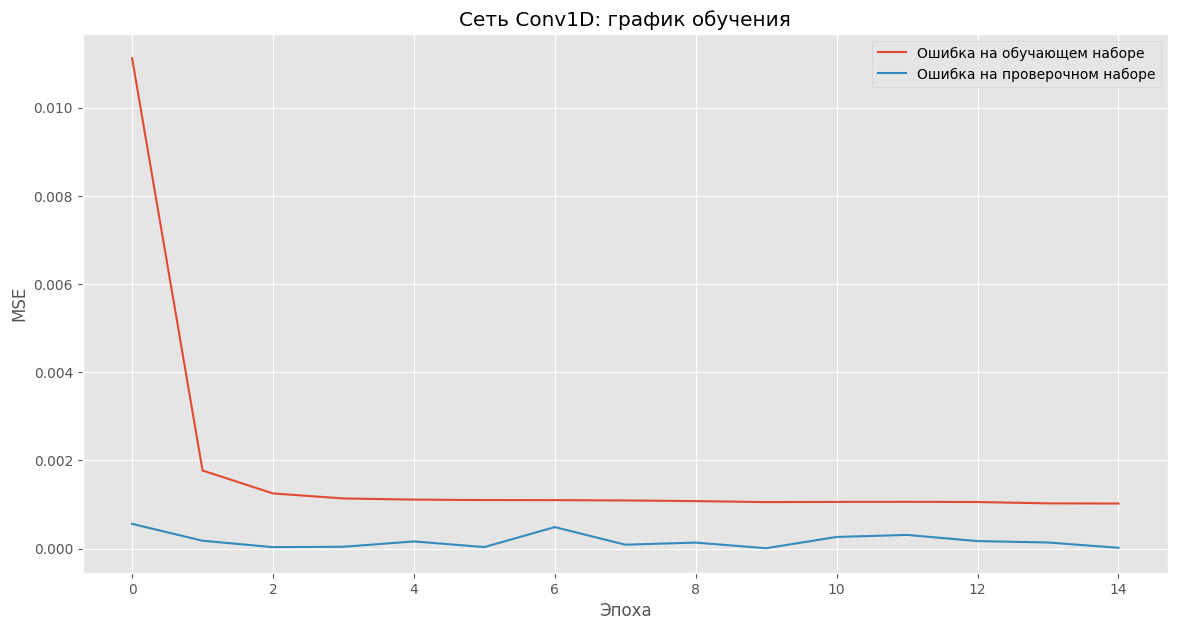

In [ ]:
# График ошибки обучения
plt.figure(figsize=(14, 7))
plt.plot(history_conv.history['loss'], label='Ошибка на обучающем наборе')
plt.plot(history_conv.history['val_loss'], label='Ошибка на проверочном наборе')
plt.title('Сеть Conv1D: график обучения')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.show()

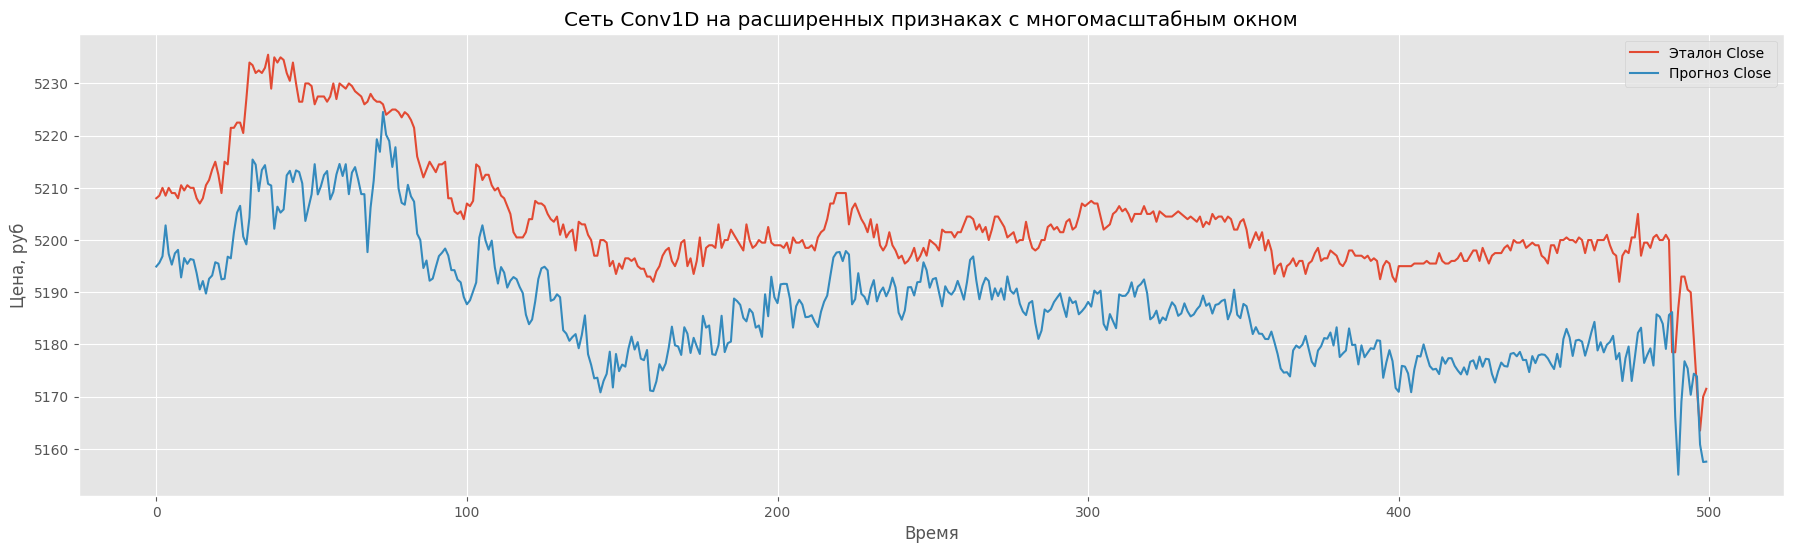

In [ ]:
# Предсказание и обратная нормализация
y_pred_conv_sc, _ = collect_predictions(model_conv, test_seq)
y_pred_conv = y_scaler.inverse_transform(y_pred_conv_sc)

# Сопоставление прогноза и эталона
start = 0
length = 500

plt.figure(figsize=(22, 6))
plt.plot(y_true_close[start:start + length], label='Эталон Close')
plt.plot(y_pred_conv[start:start + length], label='Прогноз Close')
plt.title('Сеть Conv1D на расширенных признаках с многомасштабным окном')
plt.xlabel('Время')
plt.ylabel('Цена, руб')
plt.legend()
plt.show()

## Сравнение архитектур

Чтобы оценить вклад каждой архитектуры, прогнозы обеих моделей выводятся на общем графике вместе с эталонным рядом. Для количественной оценки рассчитываются коэффициенты корреляции прогноза с эталоном и средние абсолютные ошибки.

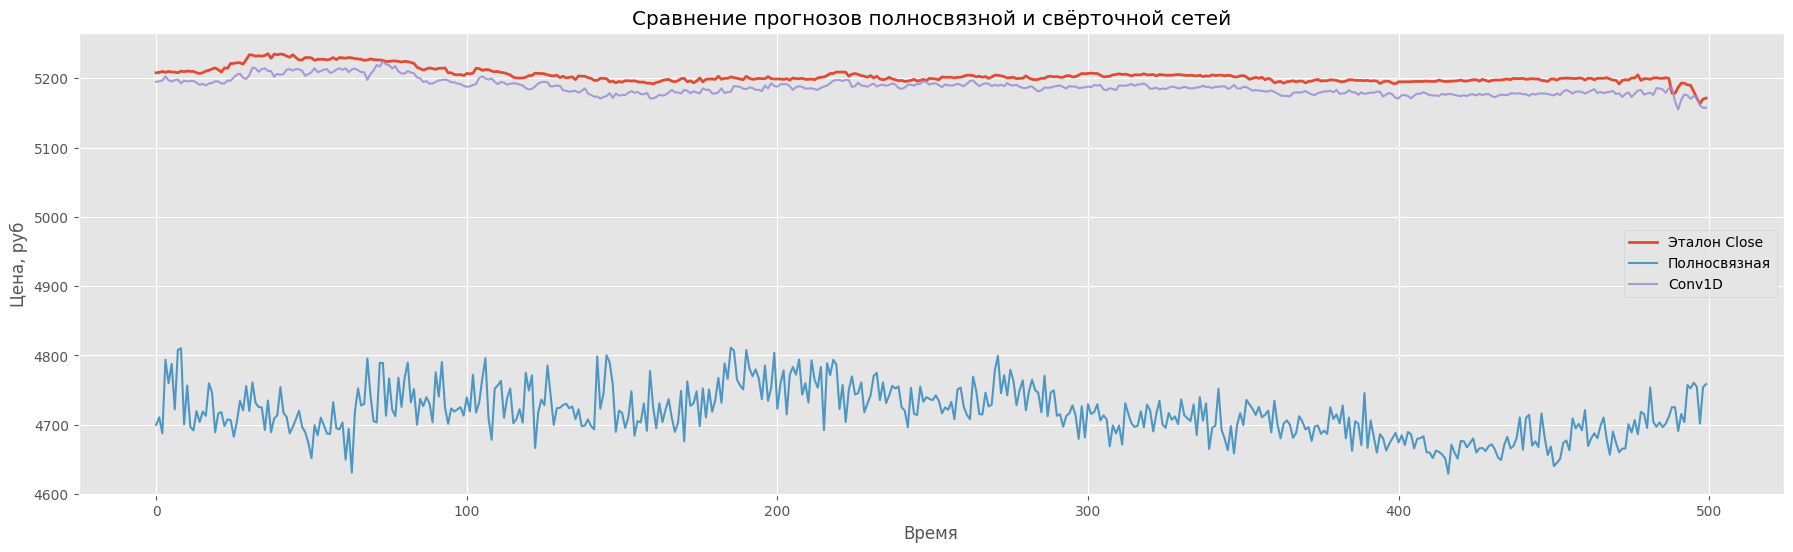

In [ ]:
# Сравнительный график
start = 0
length = 500

plt.figure(figsize=(22, 6))
plt.plot(y_true_close[start:start + length], label='Эталон Close', linewidth=2)
plt.plot(y_pred_dense[start:start + length], label='Полносвязная', alpha=0.85)
plt.plot(y_pred_conv[start:start + length], label='Conv1D', alpha=0.85)
plt.title('Сравнение прогнозов полносвязной и свёрточной сетей')
plt.xlabel('Время')
plt.ylabel('Цена, руб')
plt.legend()
plt.show()

In [ ]:
# Численная оценка качества
def report(name, y_pred, y_true):
    mae = np.mean(np.abs(y_pred - y_true))
    corr = np.corrcoef(y_pred[:, 0], y_true[:, 0])[0, 1]
    print(f'{name:20s}  MAE = {mae:8.4f}   corr = {corr:.4f}')

report('Полносвязная',   y_pred_dense, y_true_close)
report('Conv1D',         y_pred_conv,  y_true_close)

Полносвязная          MAE = 495.1249   corr = 0.8157
Conv1D                MAE =  13.5767   corr = 0.9947
